<a href="https://colab.research.google.com/github/asiddiqha/ML_Practice/blob/main/Loan_Approval_DT%2C_RF%2C_GB_%26_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import pandas for handling datasets
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Split dataset into training and testing data
from sklearn.model_selection import train_test_split
# Convert categorical values into numbers
from sklearn.preprocessing import LabelEncoder
# Import evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Import Decision Tree algorithm
from sklearn.tree import DecisionTreeClassifier
# Import Random Forest algorithm
from sklearn.ensemble import RandomForestClassifier
# Import Gradient Boosting algorithm
from sklearn.ensemble import GradientBoostingClassifier
# Import XGBoost algorithm
from xgboost import XGBClassifier

In [ ]:
# Load Dataset
file_path = "/content/Loan_Approval_Dataset_200_Rows.xlsx - Loan_Approval_Dataset.csv"
df = pd.read_csv(file_path)

In [ ]:
# ==========================================================
# DATASET OVERVIEW
# ==========================================================

print("=" * 60)
print("Dataset Shape")
print("=" * 60)
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\n" + "=" * 60)
print("Dataset Information")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("Summary Statistics")
print("=" * 60)
display(df.describe())

print("\n" + "=" * 60)
print("Missing Values")
print("=" * 60)
display(df.isnull().sum().to_frame(name="Missing Values"))

print("\n" + "=" * 60)
print("Duplicate Records")
print("=" * 60)
print(f"Number of Duplicate Rows : {df.duplicated().sum()}")

Dataset Shape
Rows    : 200
Columns : 14

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  200 non-null    int64  
 1   Annual_Income        200 non-null    int64  
 2   Credit_Score         200 non-null    int64  
 3   Employment_Status    200 non-null    object 
 4   Years_of_Experience  200 non-null    int64  
 5   Existing_Loan        200 non-null    object 
 6   Loan_Amount          200 non-null    int64  
 7   Marital_Status       200 non-null    object 
 8   Property_Area        200 non-null    object 
 9   Education            200 non-null    object 
 10  Dependents           200 non-null    int64  
 11  Loan_Term_Months     200 non-null    int64  
 12  EMI                  200 non-null    float64
 13  Loan_Approved        200 non-null    object 
dtypes: float64(1), int64(7), obj

,Age,Annual_Income,Credit_Score,Years_of_Experience,Loan_Amount,Dependents,Loan_Term_Months,EMI
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000
mean,41.035000,89114.195000,703.505000,16.180000,549000.670000,1.55000,204.000000,5280.708300
std,11.217528,35956.161268,88.003883,11.002403,257657.607831,1.08785,105.735044,3406.033181
min,21.000000,27068.000000,551.000000,0.000000,101640.000000,0.00000,60.000000,1227.150000
25%,30.750000,59181.750000,627.500000,6.000000,320352.000000,1.00000,120.000000,3150.727500
50%,42.000000,84810.500000,706.000000,16.000000,563412.500000,2.00000,180.000000,4242.665000
75%,50.250000,119990.500000,778.750000,25.000000,782833.500000,3.00000,240.000000,5886.752500
max,60.000000,149403.000000,848.000000,39.000000,990598.000000,3.00000,360.000000,18160.970000



Missing Values


,Missing Values
Age,0
Annual_Income,0
Credit_Score,0
Employment_Status,0
Years_of_Experience,0
Existing_Loan,0
Loan_Amount,0
Marital_Status,0
Property_Area,0
Education,0



Duplicate Records
Number of Duplicate Rows : 0


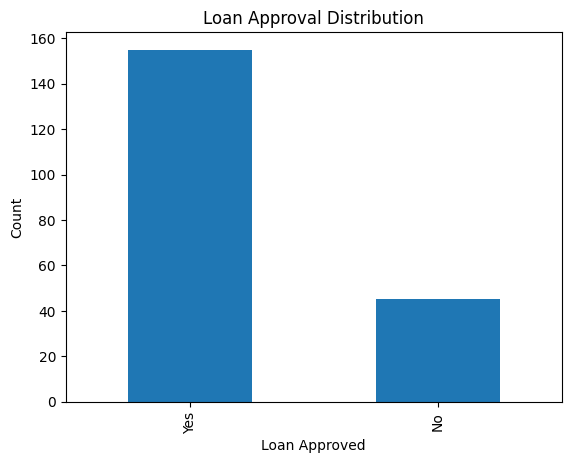

In [ ]:
## Checking whether the dataset is balanced.

df["Loan_Approved"].value_counts().plot(kind="bar")
plt.title("Loan Approval Distribution")
plt.xlabel("Loan Approved")
plt.ylabel("Count")
plt.show()

In [ ]:
# Setting Seaborn theme for plots
sns.set_theme(style="whitegrid", palette="Set2")

# Improve default figure resolution
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 120

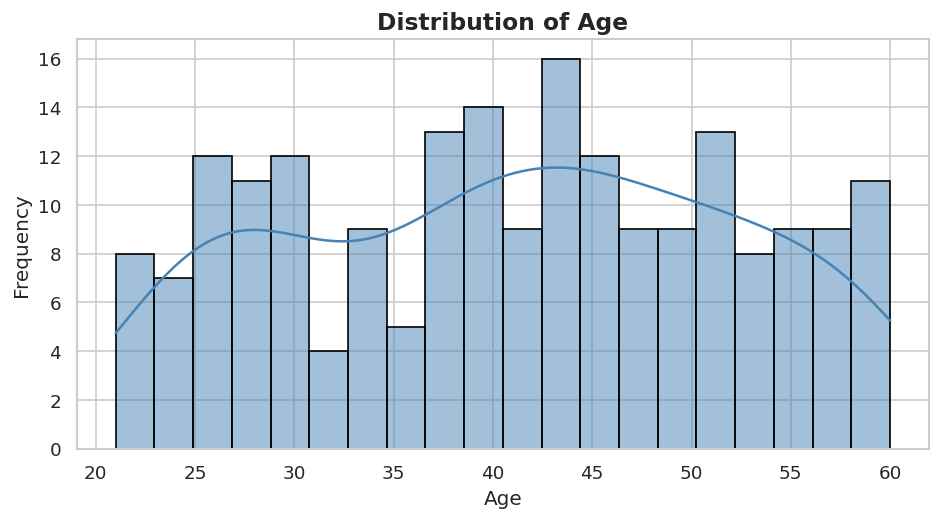

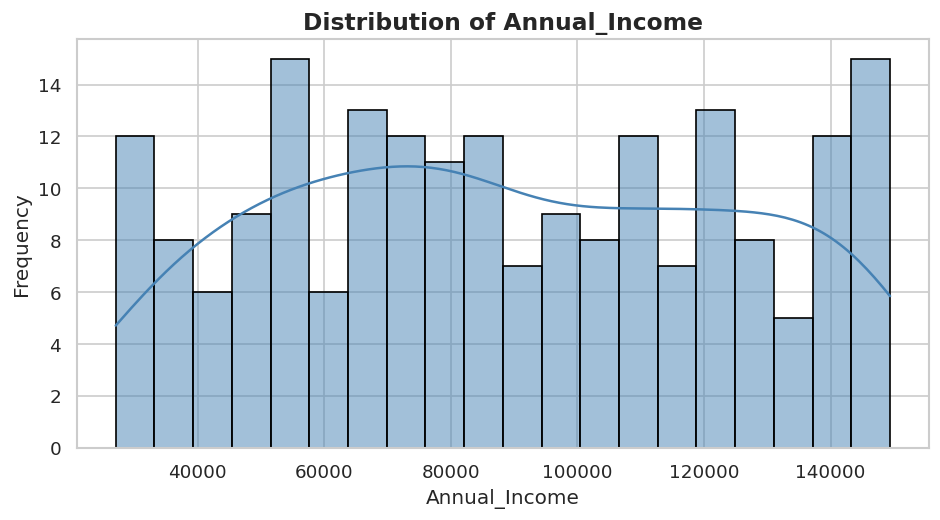

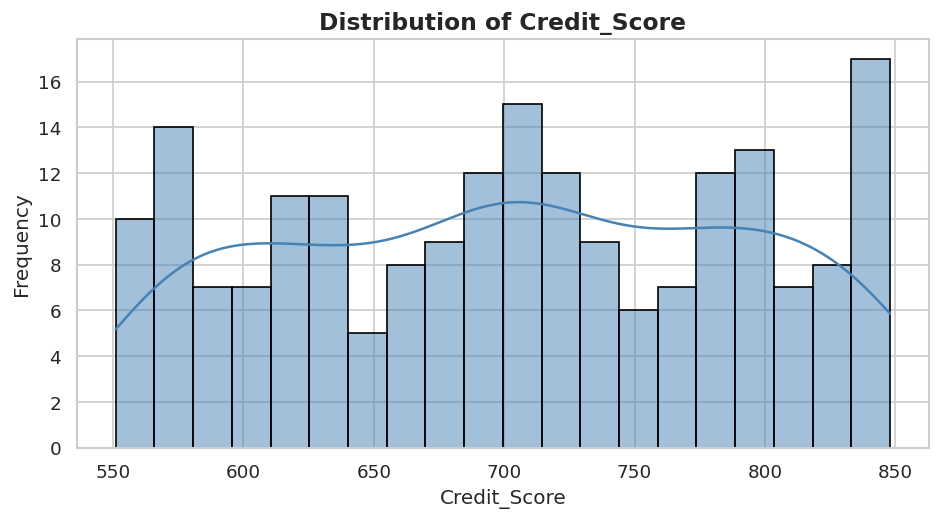

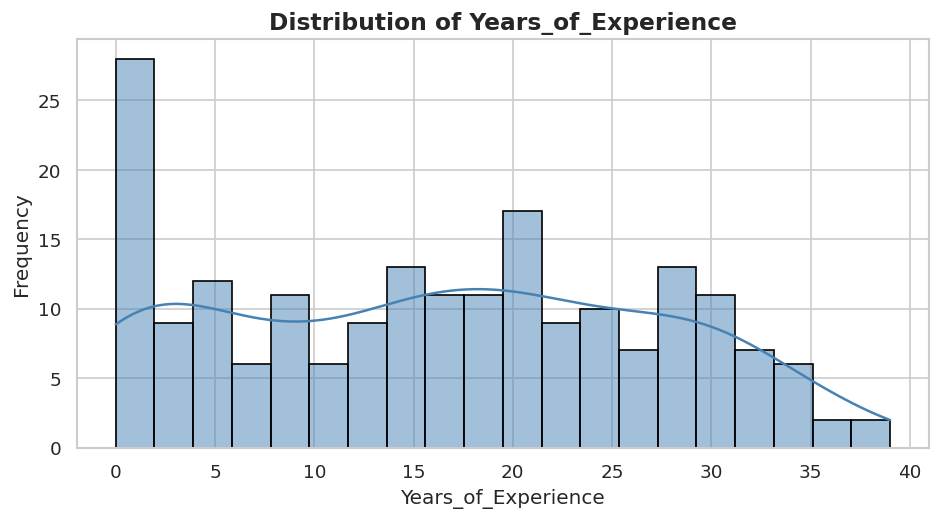

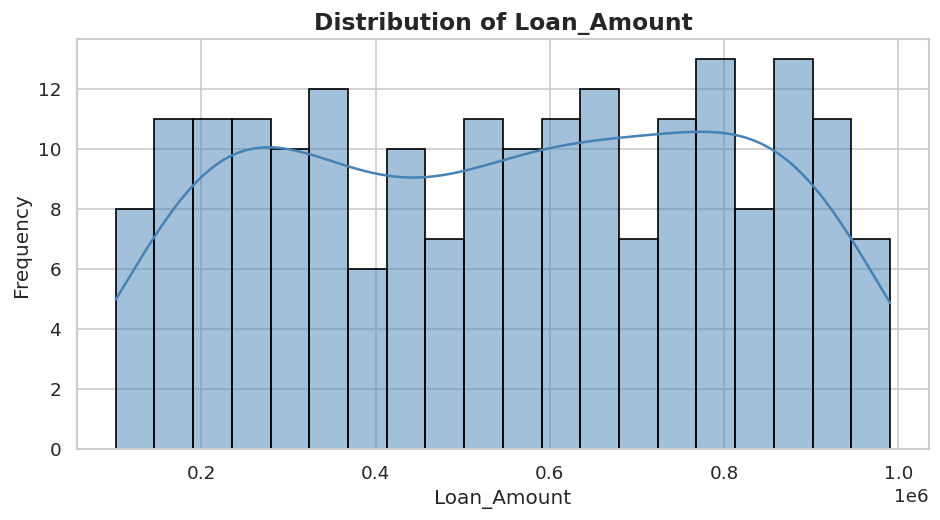

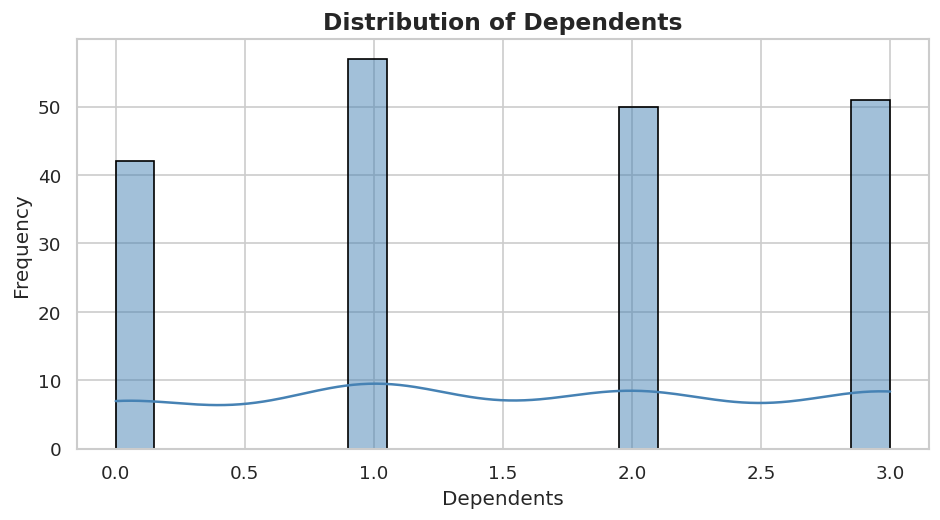

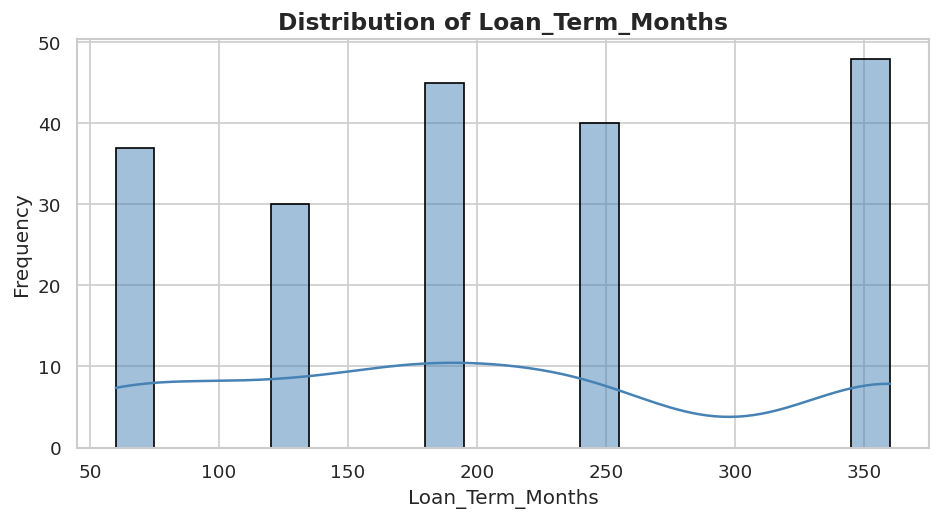

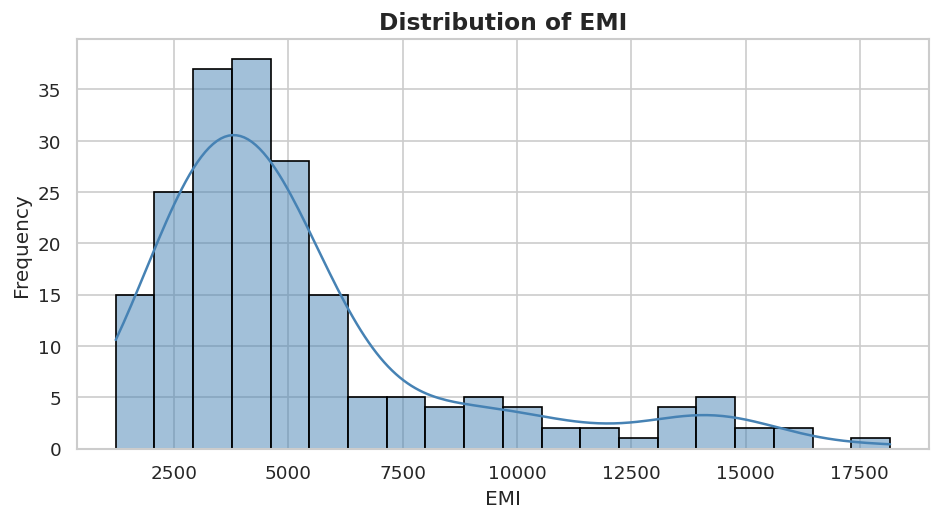

In [ ]:
# ==========================================================
# Distribution of Numerical Features
# ==========================================================
# Purpose:
# Explore the distribution of each numerical feature.
# Helps identify:
# • Data range
# • Distribution shape
# • Skewness
# • Potential outliers
# ==========================================================

# Select all numerical columns
numeric_cols = df.select_dtypes(include="number").columns

# Plot histogram for each numerical feature
for col in numeric_cols:

    plt.figure(figsize=(8,4.5))

    sns.histplot(
        data=df,
        x=col,
        bins=20,
        kde=True,
        color="steelblue",
        edgecolor="black"
    )

    plt.title(f"Distribution of {col}", fontsize=14, fontweight="bold")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_3569/2789279158.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


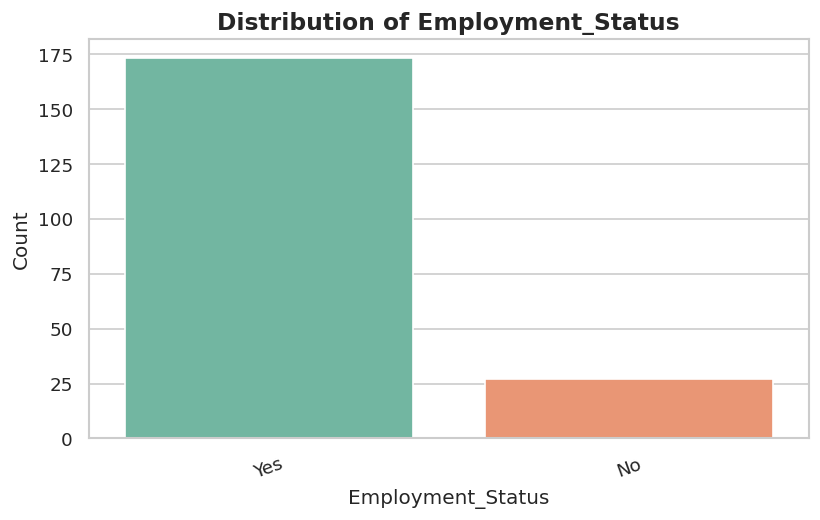

/tmp/ipykernel_3569/2789279158.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


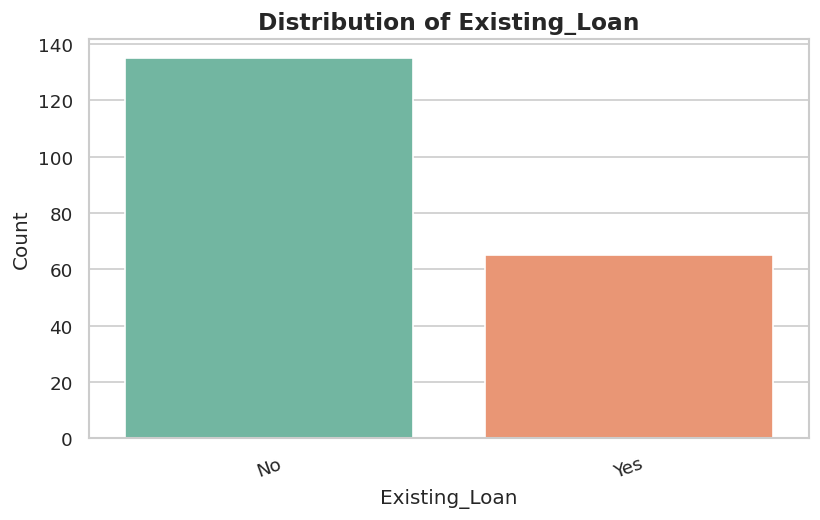

/tmp/ipykernel_3569/2789279158.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


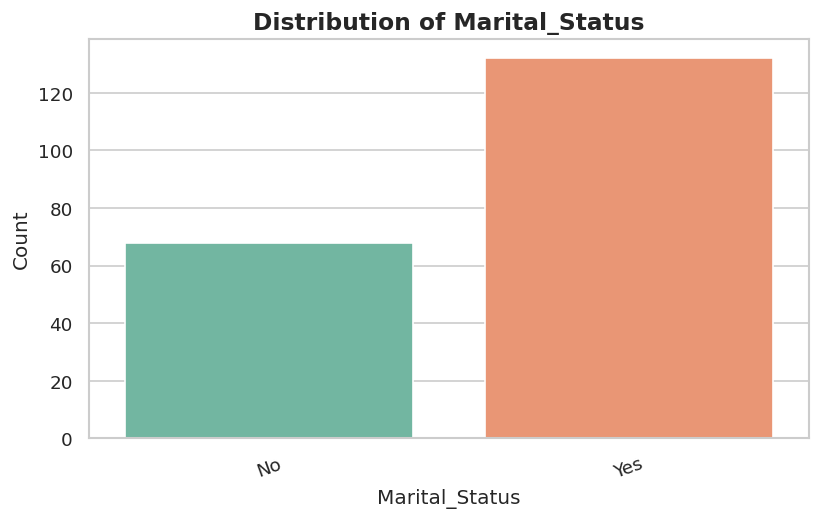

/tmp/ipykernel_3569/2789279158.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


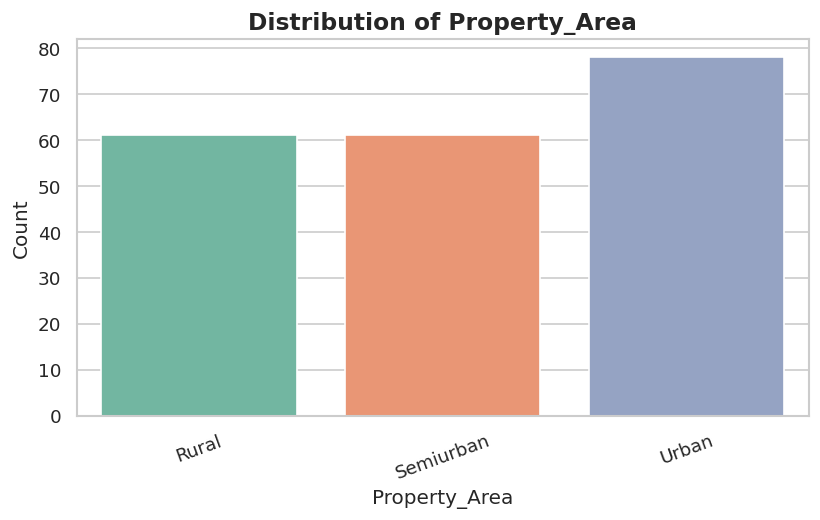

/tmp/ipykernel_3569/2789279158.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


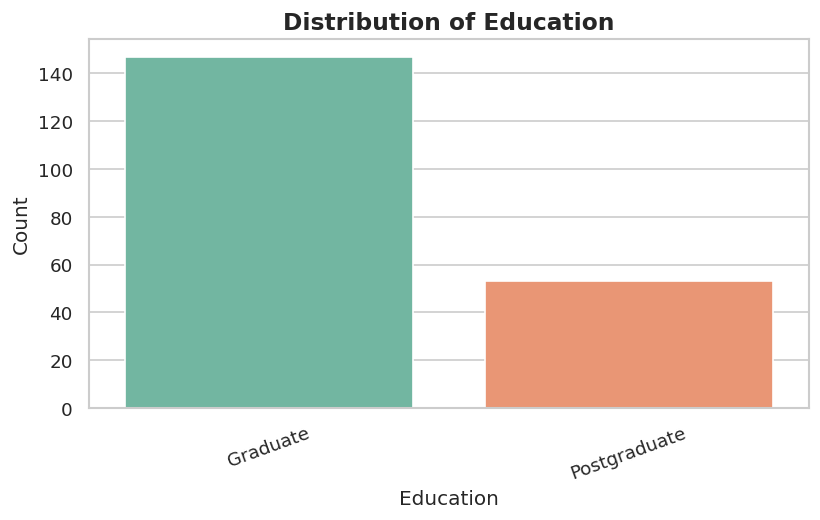

/tmp/ipykernel_3569/2789279158.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


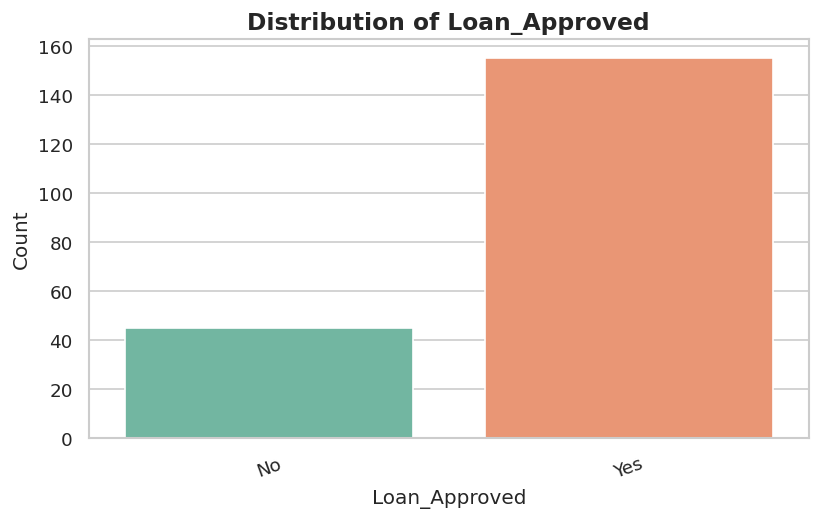

In [ ]:
# ==========================================================
# Distribution of Categorical Features
# ==========================================================
# Purpose:
# Visualize the frequency of each category.
# Helps understand class balance and category distribution.
# ==========================================================

# Select all categorical columns
categorical_cols = df.select_dtypes(include="object").columns

# Plot count plot for each categorical feature
for col in categorical_cols:

    plt.figure(figsize=(7,4.5))

    sns.countplot(
        data=df,
        x=col,
        palette="Set2"
    )

    plt.title(f"Distribution of {col}", fontsize=14, fontweight="bold")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=20)

    plt.tight_layout()
    plt.show()

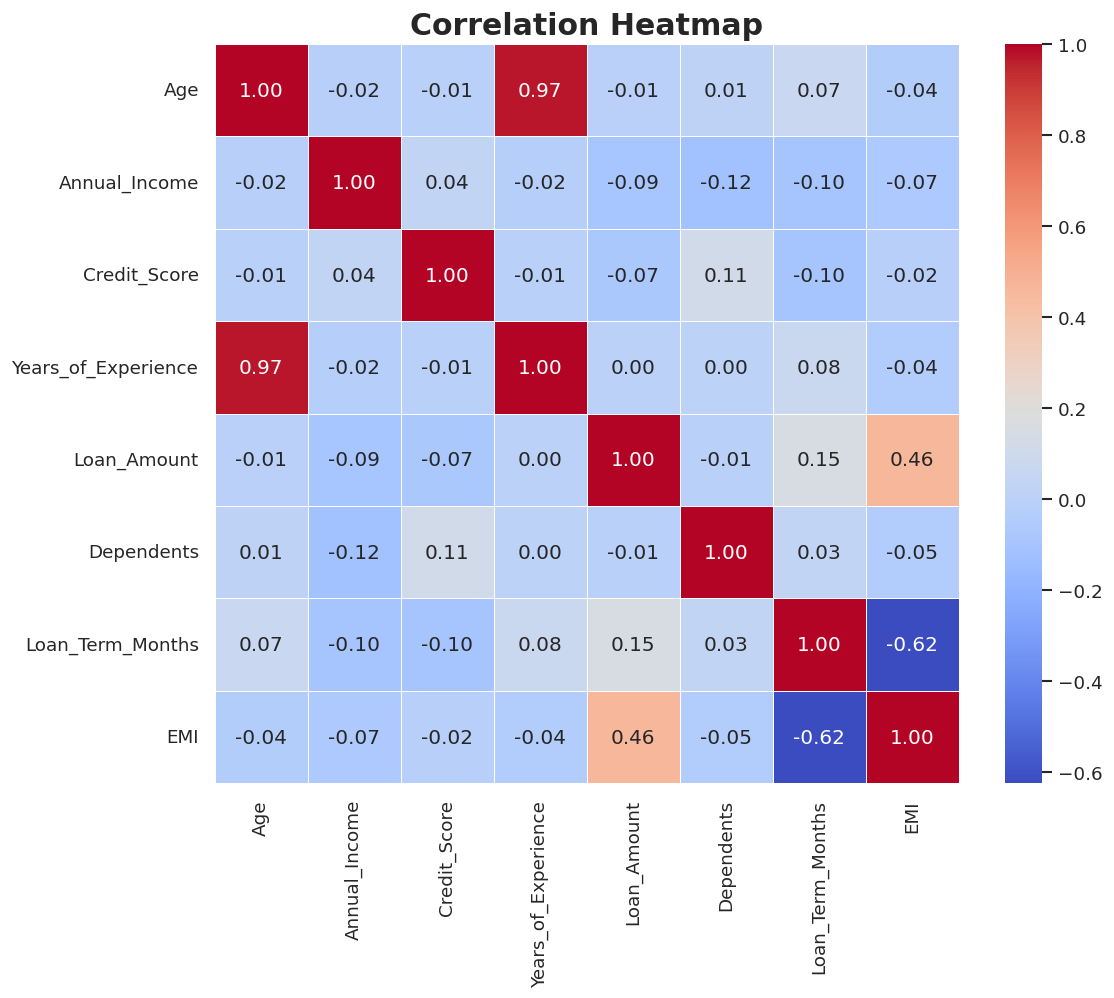

In [ ]:
# ==========================================================
# Correlation Heatmap
# ==========================================================
# Purpose:
# Shows relationships between numerical features.
#
# Helps identify:
# • Highly correlated variables
# • Positive and negative relationships
# • Features that may influence Loan Approval
# ==========================================================

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title(
    "Correlation Heatmap",
    fontsize=18,
    fontweight="bold"
)

plt.show()

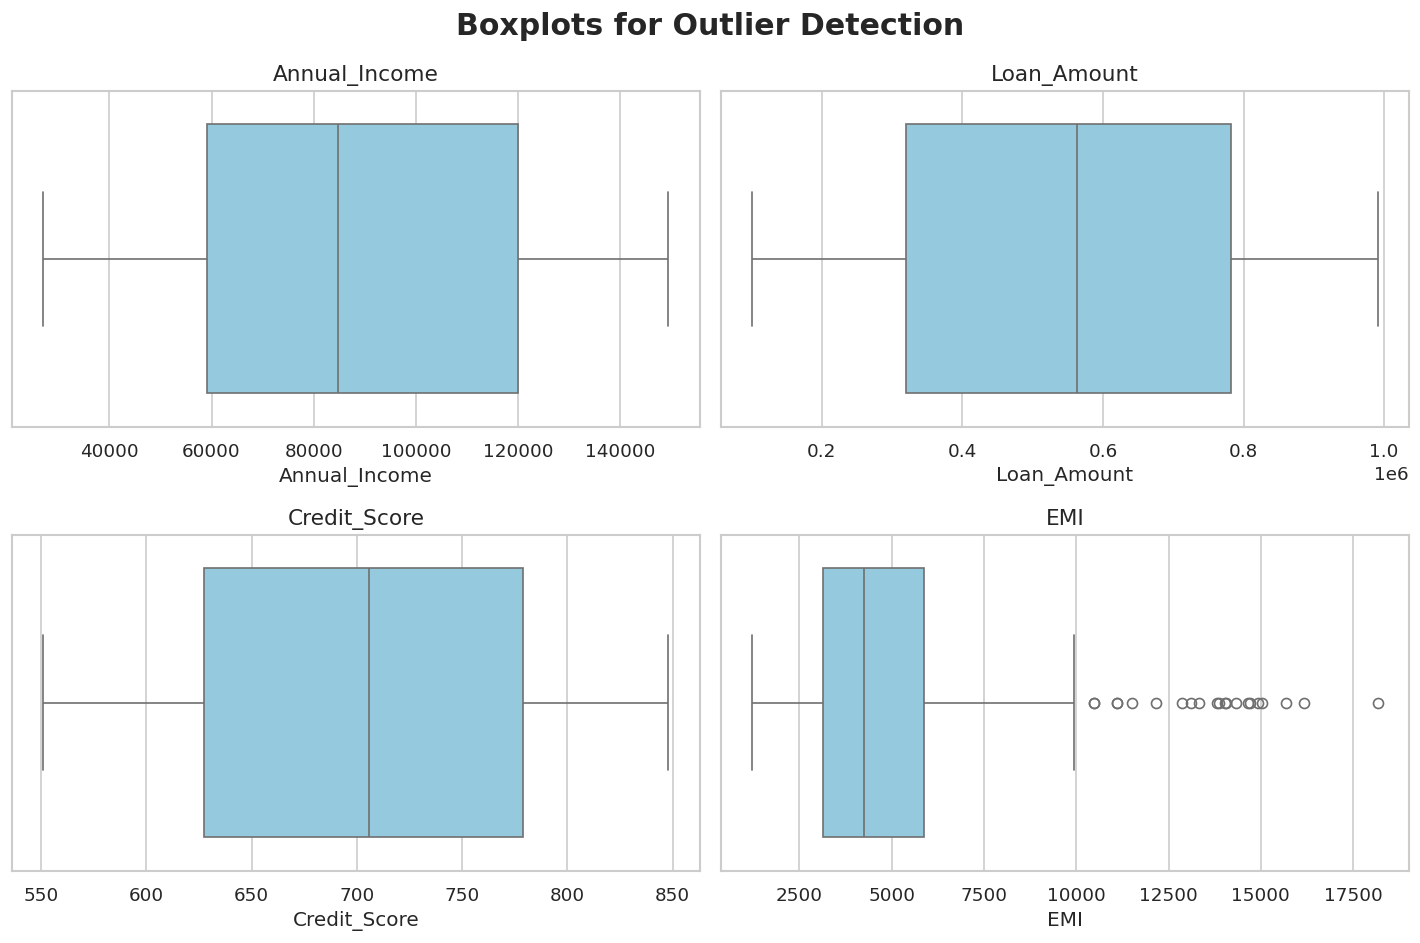

In [ ]:
# ==========================================================
# Outlier Detection using Boxplots
# ==========================================================
# Purpose:
# Detect unusually high or low values that may affect
# model performance.
# ==========================================================

outlier_columns = [
    "Annual_Income",
    "Loan_Amount",
    "Credit_Score",
    "EMI"
]

fig, axes = plt.subplots(2,2, figsize=(12,8))

for ax, column in zip(axes.flatten(), outlier_columns):

    sns.boxplot(
        x=df[column],
        ax=ax,
        color="skyblue"
    )

    ax.set_title(column, fontsize=13)

plt.suptitle(
    "Boxplots for Outlier Detection",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

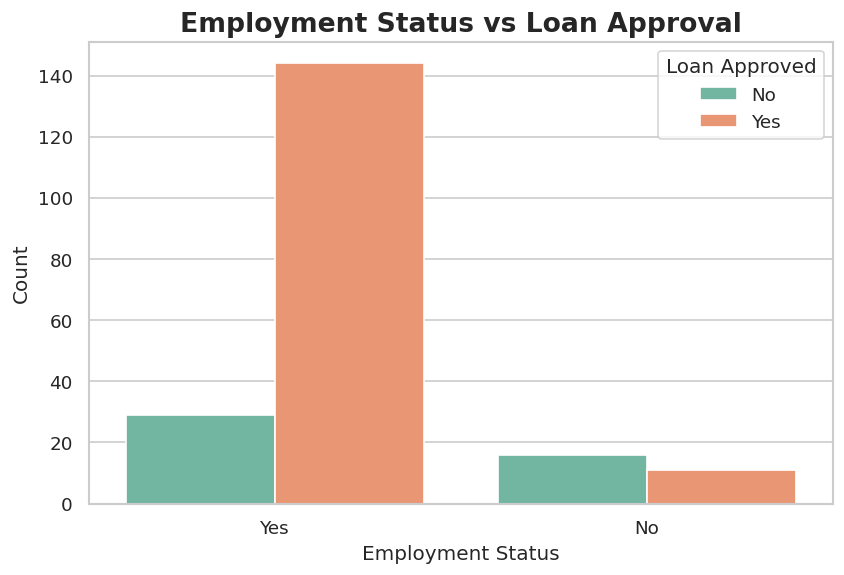

In [ ]:
# ==========================================================
# Employment Status vs Loan Approval
# ==========================================================
# Purpose:
# Examine how employment status influences
# loan approval decisions.
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Employment_Status",
    hue="Loan_Approved"
)

plt.title(
    "Employment Status vs Loan Approval",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Employment Status")
plt.ylabel("Count")

plt.legend(title="Loan Approved")

plt.show()

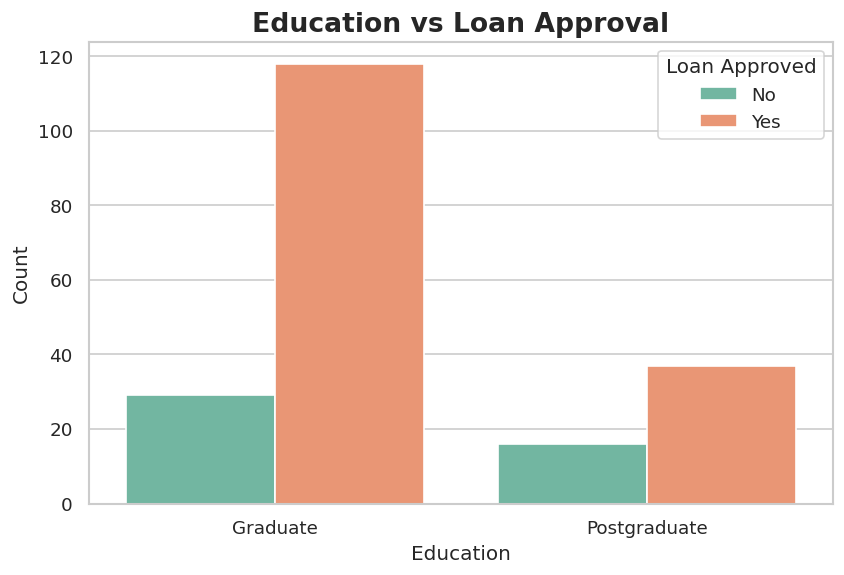

In [ ]:
# ==========================================================
# Education vs Loan Approval
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Education",
    hue="Loan_Approved"
)

plt.title(
    "Education vs Loan Approval",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Education")
plt.ylabel("Count")

plt.legend(title="Loan Approved")

plt.show()

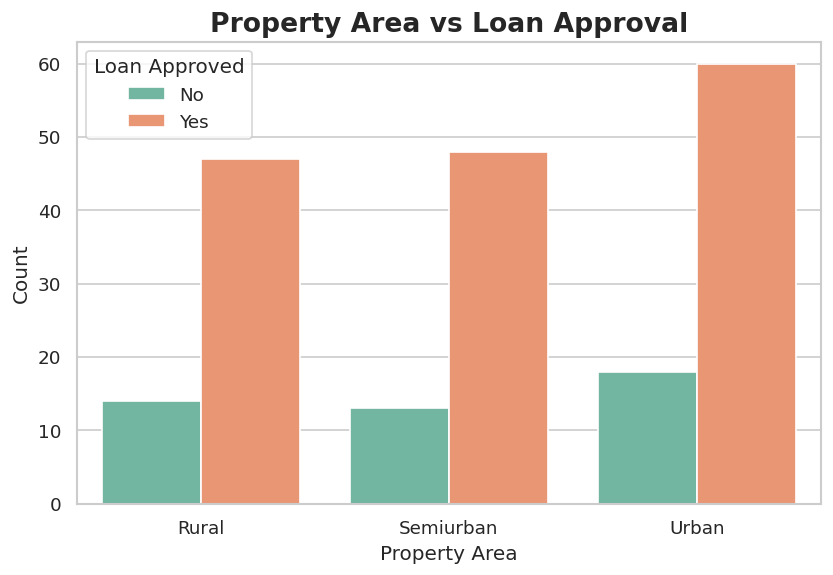

In [ ]:
# ==========================================================
# Property Area vs Loan Approval
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Property_Area",
    hue="Loan_Approved"
)

plt.title(
    "Property Area vs Loan Approval",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Property Area")
plt.ylabel("Count")

plt.legend(title="Loan Approved")

plt.show()

/tmp/ipykernel_3569/2664543763.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


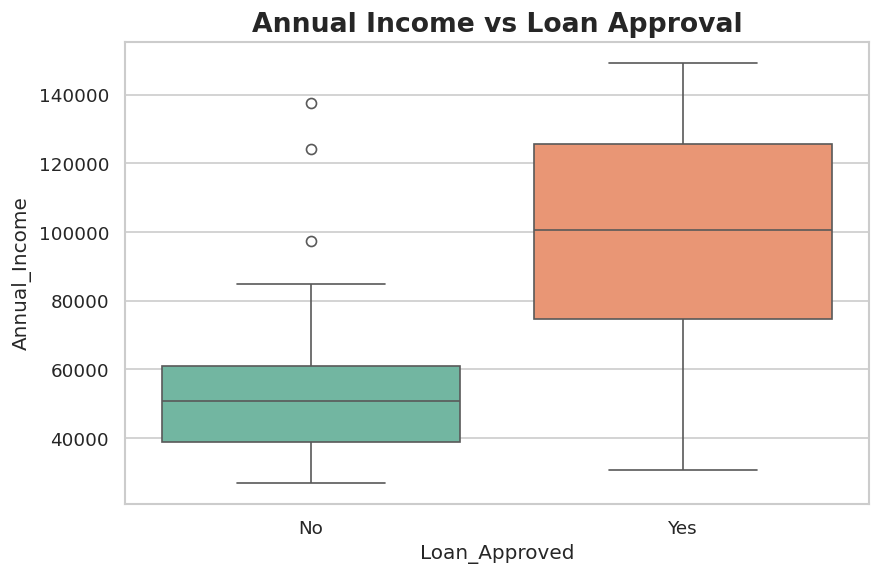

In [ ]:
# ==========================================================
# Annual Income vs Loan Approval
# ==========================================================
# Purpose:
# Compare applicant income between
# approved and rejected loans.
# ==========================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Loan_Approved",
    y="Annual_Income",
    palette="Set2"
)

plt.title(
    "Annual Income vs Loan Approval",
    fontsize=16,
    fontweight="bold"
)

plt.show()

/tmp/ipykernel_3569/1489574514.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


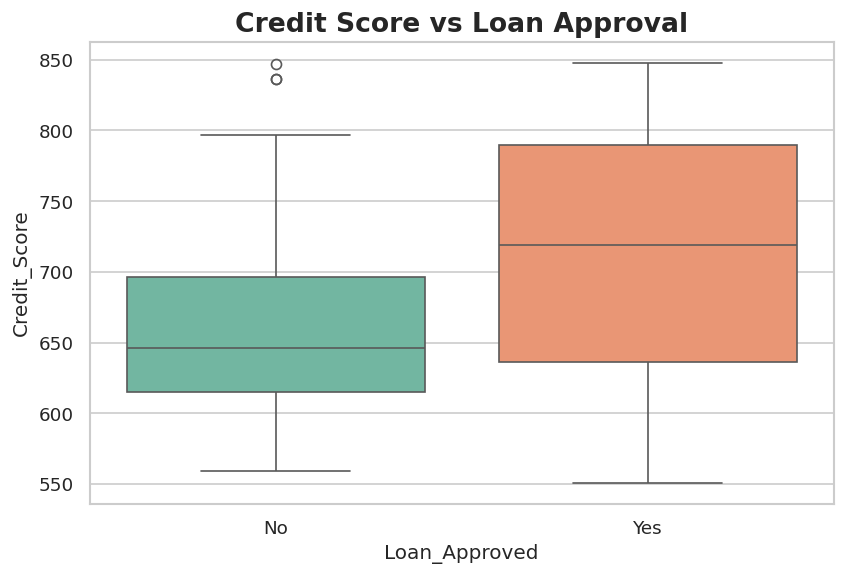

In [ ]:
# ==========================================================
# Credit Score vs Loan Approval
# ==========================================================
# Purpose:
# Credit Score is one of the strongest
# indicators for loan approval.
# ==========================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Loan_Approved",
    y="Credit_Score",
    palette="Set2"
)

plt.title(
    "Credit Score vs Loan Approval",
    fontsize=16,
    fontweight="bold"
)

plt.show()

/tmp/ipykernel_3569/1809643254.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


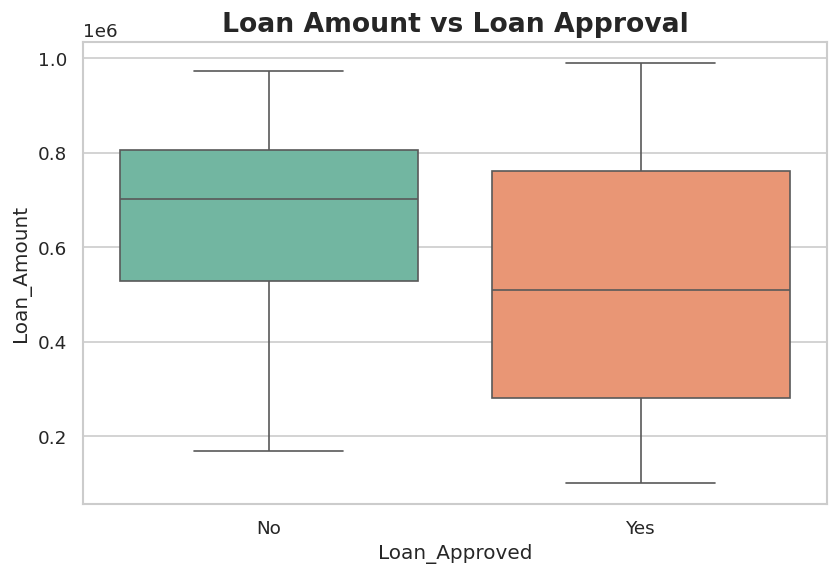

In [ ]:
# ==========================================================
# Loan Amount vs Loan Approval
# ==========================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Loan_Approved",
    y="Loan_Amount",
    palette="Set2"
)

plt.title(
    "Loan Amount vs Loan Approval",
    fontsize=16,
    fontweight="bold"
)

plt.show()

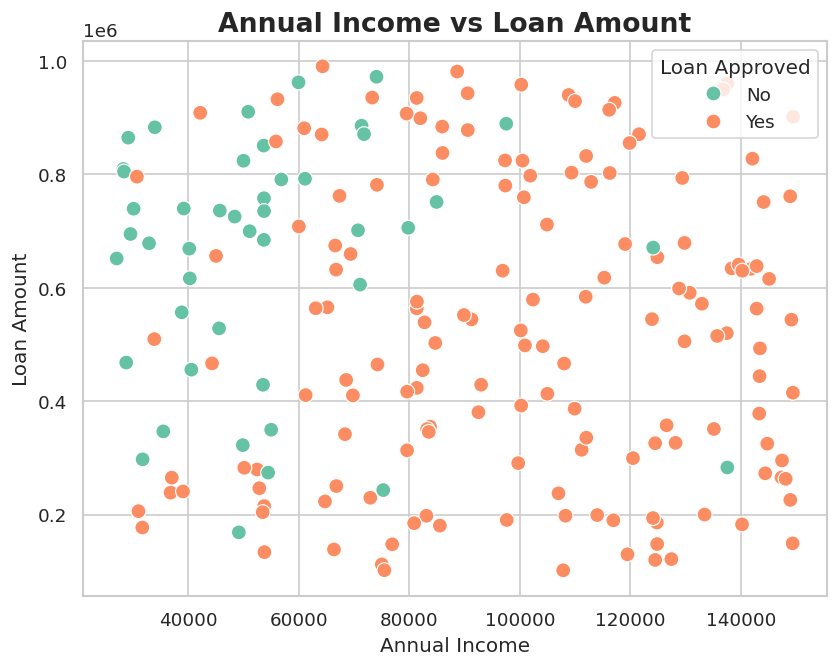

In [ ]:
# ==========================================================
# Annual Income vs Loan Amount
# ==========================================================
# Purpose:
# Visualize relationship between
# applicant income and requested loan amount.
# ==========================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Annual_Income",
    y="Loan_Amount",
    hue="Loan_Approved",
    s=80
)

plt.title(
    "Annual Income vs Loan Amount",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Annual Income")
plt.ylabel("Loan Amount")

plt.legend(title="Loan Approved")

plt.show()

In [ ]:
# ==========================================================
# Label Encoding
# ==========================================================
# Purpose:
# Convert all categorical (object) columns into numerical values
# required by machine learning algorithms.
# ==========================================================

from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder object
le = LabelEncoder()

# Select all categorical columns
categorical_cols = df.select_dtypes(include="object").columns

# Apply Label Encoding
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("Label Encoding Completed Successfully!")

Label Encoding Completed Successfully!


In [ ]:
# X contains independent variables
X = df.drop("Loan_Approved", axis=1)

# y contains dependent variable (Target)
y = df["Loan_Approved"]

In [ ]:
# Splitting dataset into Training and Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Create Decision Tree model
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
accuracy_score(y_test, y_pred_dt)

# Print Accuracy
print("Decision Tree Accuracy:",
accuracy_score(y_test, y_pred_dt))
# Print Confusion Matrix
print(confusion_matrix(y_test, y_pred_dt))
# Print Classification Report
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7
[[ 4  6]
 [ 6 24]]
              precision    recall  f1-score   support

           0       0.40      0.40      0.40        10
           1       0.80      0.80      0.80        30

    accuracy                           0.70        40
   macro avg       0.60      0.60      0.60        40
weighted avg       0.70      0.70      0.70        40



In [ ]:
# Create Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
accuracy_score(y_test, y_pred_rf)

# Accuracy
print("Random Forest Accuracy:",
accuracy_score(y_test, y_pred_rf))
# Confusion Matrix
print(confusion_matrix(y_test, y_pred_rf))
# Classification Report
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.775
[[ 4  6]
 [ 3 27]]
              precision    recall  f1-score   support

           0       0.57      0.40      0.47        10
           1       0.82      0.90      0.86        30

    accuracy                           0.78        40
   macro avg       0.69      0.65      0.66        40
weighted avg       0.76      0.78      0.76        40



In [ ]:
# Create Gradient Boosting model
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
accuracy_score(y_test, y_pred_gb)

# Accuracy
print("Gradient Boosting Accuracy:",
accuracy_score(y_test, y_pred_gb))
# Confusion Matrix
print(confusion_matrix(y_test, y_pred_gb))
# Classification Report
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.85
[[ 7  3]
 [ 3 27]]
              precision    recall  f1-score   support

           0       0.70      0.70      0.70        10
           1       0.90      0.90      0.90        30

    accuracy                           0.85        40
   macro avg       0.80      0.80      0.80        40
weighted avg       0.85      0.85      0.85        40



In [ ]:
# Create XGBoost model
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
accuracy_score(y_test, y_pred_xgb)

# Accuracy
print("XGBoost Accuracy:",
accuracy_score(y_test, y_pred_xgb))
# Confusion Matrix
print(confusion_matrix(y_test, y_pred_xgb))
# Classification Report
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.8
[[ 6  4]
 [ 4 26]]
              precision    recall  f1-score   support

           0       0.60      0.60      0.60        10
           1       0.87      0.87      0.87        30

    accuracy                           0.80        40
   macro avg       0.73      0.73      0.73        40
weighted avg       0.80      0.80      0.80        40



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:26:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
# Store all model accuracies
results = {
"Decision Tree": accuracy_score(y_test, y_pred_dt),
"Random Forest": accuracy_score(y_test, y_pred_rf),
"Gradient Boosting": accuracy_score(y_test, y_pred_gb),
"XGBoost": accuracy_score(y_test, y_pred_xgb)
}
# Print model comparison
for model, score in results.items():
  print(f"{model}: {score:.2%}")

Decision Tree: 70.00%
Random Forest: 77.50%
Gradient Boosting: 85.00%
XGBoost: 80.00%
